# Conditional information footprints

Reg-Seq data: for each promoter and growth condition, a table of sequence variants with
RNA and DNA read counts. Variants are random mutants of a ~160 bp wild-type promoter.
The existing analysis (`regseq2.compute_MI`) computes, per position, the mutual
information between mutation state (mutated vs. WT) and read class (RNA vs. DNA), and
calls peaks against a permutation null in which (RNA, DNA) count tuples are reassigned
to variants.

The problem: positions in the library are not independent. A position that happens to
co-occur with a causal mutation inherits apparent information from it. The marginal
per-position MI does not remove this, so the caller can produce peaks at positions that
are not binding sites.

The approach tried here: replace the marginal statistic with a conditional one by
fitting all positions jointly in a single logistic model, then calibrate against a
permutation null that holds the mutation matrix fixed.

**How this notebook is built.** This is exploratory work, not a package: every
non-trivial choice is explained in the markdown cell above the code that makes it,
cells are kept small and rerunnable, and intermediate arrays are kept in memory under
plain names rather than hidden inside functions. The notebook stops at three
checkpoints (end of Sections 1, 3, 6) to show intermediate results before continuing —
this file currently goes only as far as **CHECKPOINT 1**.

## Section 0 — Setup and parameters

Standard scientific-Python stack plus `statsmodels` for the logistic GLM used from
Section 3 onward, and `regseq2` for the two pieces of the existing pipeline this
notebook builds on directly: `get_counts` (raw per-barcode DNA/RNA counts) and
`compute_MI` (the existing marginal-MI statistic, used here as a reference to validate
against, not reimplemented).

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy
from scipy import stats

import regseq2
from regseq2 import get_counts, compute_MI

regseq2.viz.matplotlib_style()

All run parameters in one place, so nothing that matters is buried in a code cell
further down.

- `PROMOTER` / `IND` pick `araBp` under arabinose induction (growth-condition index 3,
  replicate 1). This is the worked example used elsewhere in this repo, which matters
  for Section 2: the marginal footprint computed here needs an existing result to
  validate against, and it also has annotated binding sites (araI1/araI2, CRP, RNAP)
  to reason about later.
- `N_PERMUTATIONS` starts at the spec's suggested 1000; Section 4 checks explicitly
  whether that is deep enough for the tail quantiles peak-calling needs, rather than
  assuming it.
- `SEED_QUANTILE` / `EXTEND_QUANTILE` are left as `None` on purpose. Section 5 is the
  peak-calling logic, but the actual quantile values are not chosen there — Section 6
  runs a simulation with known-true blocks and reads the thresholds off that. Setting
  numbers here now would mean picking them by eye and rationalizing it later.

In [2]:
PROMOTER = "araBp"
IND = "3-1"              # growth condition 3 = arabinose, replicate 1
IND_REPLICATE_2 = "3-2"  # used only in Section 7, for the replicate comparison

DATA_DIR = regseq2.analysis.DATA_DIR
WT_SEQUENCES_CSV = f"{DATA_DIR}/metadata/wt_sequences.csv"

N_PERMUTATIONS = 1000
RNG_SEED = 0
RNG = np.random.default_rng(RNG_SEED)

SEED_QUANTILE = None    # set in Section 7, from the Section 6 sweep
EXTEND_QUANTILE = None  # set in Section 7, from the Section 6 sweep
MIN_CALL_WIDTH = 6      # positions; fixed by the spec, not tuned

## Section 1 — Data and the mutation matrix

Load the raw per-variant counts and WT sequence, build the mutation matrix `M` that
every later section fits against, and — before trusting anything downstream — run the
diagnostics that determine whether the whole conditional-model idea is even addressing
the right mechanism for this promoter/condition.

### Loading the per-variant table

`get_counts` is the same loader the existing marginal-footprint pipeline uses
(`regseq2.analysis.get_counts`): it reads the DNA and RNA barcode-count files for
`IND`, outer-joins them on barcode, fills unobserved counts with 0, and inner-joins
against the barcode→promoter mapping table, then filters to `PROMOTER`. Reusing it
means this notebook starts from exactly the same rows as the statistic it's trying to
improve on, rather than a second, possibly-divergent parser.

The spec is explicit about not assuming column names, so the next cell prints what's
actually there before anything downstream relies on it.

In [3]:
df_counts = get_counts(IND, PROMOTER)
print(df_counts.shape)
print(df_counts.dtypes)
df_counts.head()

(6131, 7)
ct_0          float64
barcode        object
ct_1          float64
Unnamed: 0      int64
promoter       object
count           int64
name           object
dtype: object


,ct_0,barcode,ct_1,Unnamed: 0,promoter,count,name
62,1.0,AAAAAACGTGTCGGTCGCTG,0.0,42820,TCCACAGTGATTATTTGCACGACGCCACGATTTGCTATGCCATAGC...,147,araBp
145,2.0,AAAAACAACAGAGACTGGGA,0.0,34332,TCCAAATTGATTATTTGAACGGCGTCACAGTTTGCTCTGCCATTGC...,29,araBp
202,1.0,AAAAACCGATCAGGGGGTGA,0.0,44178,TCCACATAAATTATTTGCACGGTGTCGCACTTTGCTATGCCAGAGC...,31,araBp
261,0.0,AAAAACTACCTTTGGTTGAG,2.0,91444,TCCACATTGATTATTTGCACGGCGTCACACTTTGTTATGCCGTAGT...,69,araBp
311,1.0,AAAAAGATCCTGCCTGTTCG,0.0,59722,TCCACATTGACTATTTGCACGGCGTAACACTGGGCTATGCCATAGC...,110,araBp


One row per barcode, not per unique sequence — the same barcode can be the only
tag on its exact mutant sequence, or one of several. `ct_0` is the DNA (input-library)
count, `ct_1` is the RNA (transcript) count. `Unnamed: 0` and `count` come along from
the barcode→promoter mapping table (a row index and a mapping-confidence count from
the barcode-calling step); neither is a DNA/RNA read count and neither is used below.

In [4]:
print("unique barcodes:", df_counts["barcode"].nunique(), " rows:", len(df_counts))
print("unique sequences:", df_counts["promoter"].nunique())
print("sequence length(s) seen:", sorted(df_counts["promoter"].astype(str).str.len().unique()))

unique barcodes: 6131  rows: 6131
unique sequences: 1647
sequence length(s) seen: [np.int64(160)]


### WT sequence

Loaded independently from `wt_sequences.csv`, not derived from the variant table, so a
corrupted or truncated variant sequence would show up as a length mismatch below
instead of silently producing a malformed `M`.

In [5]:
df_wt = pd.read_csv(WT_SEQUENCES_CSV)
print(df_wt.columns.tolist())

wt_seq = df_wt.loc[df_wt["promoter"] == PROMOTER, "promoter_seq"].values[0]
L = len(wt_seq)
print(f"{PROMOTER} WT length: {L}")
assert (df_counts["promoter"].astype(str).str.len() == L).all(), "variant/WT length mismatch"

['genes', 'sequence', 'promoter', 'promoter_seq', 'fwd_primer', 'rev_primer1', 'rev_primer2', 'rev_primer3', 'upstream_re_site', 'downstream_re_site', 'name']
araBp WT length: 160


### Dropping zero-read variants

A barcode with zero total reads (present in neither the DNA nor the RNA library after
the outer join — e.g. only ever seen in the mapping step) carries no information about
its RNA-vs-DNA read class; it can't contribute to any MI or GLM computation below, only
add a `0/0` row. The spec is explicit that this is the *only* filter applied here — no
minimum-depth cutoff, no leverage/outlier trimming. Those are principled interventions
that belong in a later, motivated stage (if anywhere), not silently folded into
"loading the data.

In [6]:
total_reads_per_variant = df_counts["ct_0"] + df_counts["ct_1"]
n_zero_read = int((total_reads_per_variant == 0).sum())

df_var = df_counts.loc[total_reads_per_variant > 0].reset_index(drop=True)
print(f"dropped {n_zero_read} / {len(df_counts)} variants with zero total reads")
print(f"remaining: {len(df_var)} variants")

dropped 0 / 6131 variants with zero total reads
remaining: 6131 variants


### Building `M`, `n_rna`, `n_dna`, and the position axis

`M` is `n_variants × L`, 1 where a variant's base differs from WT at that position, 0
otherwise — built as a single vectorized byte comparison (`frombuffer` + reshape)
rather than a Python loop over variants, since this needs to run once here and then
again inside every permutation refit in Section 4.

One row per barcode (not deduplicated to one row per unique sequence) — the same
granularity `compute_MI` already uses for the marginal statistic. The alternative,
collapsing barcodes that share a sequence into a single variant with pooled counts,
would change what "one data point" means between this notebook and the existing
pipeline, and Section 2 needs the two to agree to numerical precision. It would also
throw away real information: two barcodes on the same sequence are still two
independent physical clones, each with its own sequencing depth.

`pos` runs -115..+44 relative to the TSS, matching the axis every existing footprint
plot in this repo uses, so figures here can be compared directly to those.

In [7]:
seqs = df_var["promoter"].astype(str)
seq_arr = np.frombuffer("".join(seqs.values).encode("ascii"), dtype=np.uint8).reshape(len(seqs), L)
wt_arr = np.frombuffer(wt_seq.encode("ascii"), dtype=np.uint8)
M = (seq_arr != wt_arr[None, :]).astype(np.float64)

n_rna = df_var["ct_1"].values.astype(np.int64)
n_dna = df_var["ct_0"].values.astype(np.int64)
pos = np.arange(-115, 45)

assert M.shape == (len(df_var), L) == (len(df_var), len(pos))
print("M:", M.shape, " n_rna, n_dna:", n_rna.shape, n_dna.shape)

M: (6131, 160)  n_rna, n_dna: (6131,) (6131,)


### Diagnostic 1 — library composition and effective sample size

`n_variants` overstates how much statistical power is actually available if a small
number of barcodes carry most of the reads: a variant with 10,000 reads and one with 10
reads are not equally informative data points. `frac_top1pct` is the share of all reads
held by the top 1% most-sequenced variants — a direct check for that kind of skew.
`eff_n = (Σw)²/Σw²` with `w = n_rna + n_dna` is Kish's effective sample size for a
depth-weighted statistic: it answers "how many equal-depth variants would give the same
precision as what we actually have," and is the number to compare against `n_variants`,
not `n_variants` itself.

In [8]:
n_variants = M.shape[0]
w = (n_rna + n_dna).astype(np.float64)
total_reads = w.sum()

top1pct_threshold = np.quantile(w, 0.99)
frac_top1pct = w[w >= top1pct_threshold].sum() / total_reads
eff_n = w.sum()**2 / (w**2).sum()

print(f"n_variants        = {n_variants}")
print(f"total_reads        = {total_reads:.0f}")
print(f"frac_top1pct       = {frac_top1pct:.3f}")
print(f"eff_n              = {eff_n:.1f}  ({eff_n / n_variants:.1%} of n_variants)")

n_variants        = 6131
total_reads        = 16693
frac_top1pct       = 0.131
eff_n              = 1738.7  (28.4% of n_variants)


### Diagnostic 2 — per-position mutation rate

Below ~2% mutated, very few variants carry any information about that position, so both
the marginal MI and (from Section 3 on) that position's logistic coefficient are
estimated from a small effective sample there specifically — worth flagging before
either statistic is trusted position-by-position. Above 50%, "mutated" is the majority
class rather than the rare-perturbation class the whole design assumes, which changes
how the sign/magnitude of an effect should be read. Both thresholds are diagnostic
flags only; per the previous cell's filter, nothing is dropped because of this.

In [9]:
mut_rate = M.mean(axis=0)
flagged_positions = pos[(mut_rate < 0.02) | (mut_rate > 0.5)]

print(f"mutation rate range: {mut_rate.min():.3f} - {mut_rate.max():.3f}")
print(f"positions flagged (rate < 0.02 or > 0.5): {len(flagged_positions)}")
if len(flagged_positions):
    print(flagged_positions)

mutation rate range: 0.074 - 0.146
positions flagged (rate < 0.02 or > 0.5): 0


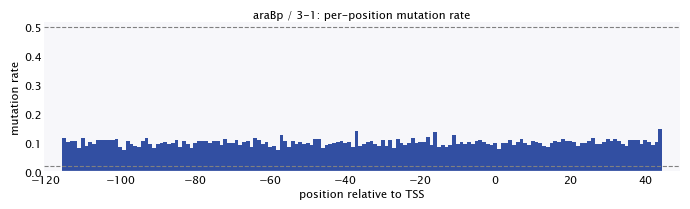

In [10]:
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.bar(pos, mut_rate, width=1, color=regseq2.viz.my_color_dict["blue1"])
ax.axhline(0.02, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("position relative to TSS")
ax.set_ylabel("mutation rate")
ax.set_title(f"{PROMOTER} / {IND}: per-position mutation rate")
fig.tight_layout()

### Diagnostic 3 — pairwise correlation between positions

This is the mechanism the whole notebook is testing for. If mutations at different
positions are correlated across the variant library (by design or by chance, in a
library this size), a position near a true causal site can pick up "borrowed" MI purely
through that correlation, without itself doing anything. `R = corrcoef(M.T)` is the
`L × L` correlation matrix between position-columns of `M`; the diagonal is trivially 1
and is masked in the plot (and zeroed before any downstream use of `R`, so it can never
count a position as leaking into itself).

In [11]:
R = np.corrcoef(M.T)
R_display = R.copy()
np.fill_diagonal(R_display, np.nan)
np.fill_diagonal(R, 0.0)  # zero, not nan: R is used in arithmetic below

i_max, j_max = np.unravel_index(np.argmax(np.abs(R)), R.shape)
print(f"largest |off-diagonal r| = {np.abs(R[i_max, j_max]):.3f}  "
      f"(positions {pos[i_max]} and {pos[j_max]})")

largest |off-diagonal r| = 0.111  (positions -17 and 41)


`r²` decay with separation: bin position pairs by `|i-j|` and average `r²` within each
bin. A library with clustered mutations (e.g. multiple mutations preferentially placed
near each other) would show `r²` falling off with distance; a library where mutations
land independently should show a flat, noisy line at roughly the sampling-noise floor
regardless of separation.

In [12]:
sep = np.abs(np.subtract.outer(np.arange(L), np.arange(L)))
iu = np.triu_indices(L, k=1)
sep_flat, r2_flat = sep[iu], (R**2)[iu]

bins = np.arange(0, sep_flat.max() + 5, 5)
bin_idx = np.digitize(sep_flat, bins)
mean_r2_by_sep = np.array([
    r2_flat[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
    for b in range(1, len(bins))
])

near = r2_flat[sep_flat <= 20].mean()
far = r2_flat[sep_flat > 20].mean()
print(f"mean r^2, separation <=20 bp: {near:.5f}   >20 bp: {far:.5f}   ratio: {near/far:.2f}")

mean r^2, separation <=20 bp: 0.00096   >20 bp: 0.00095   ratio: 1.01


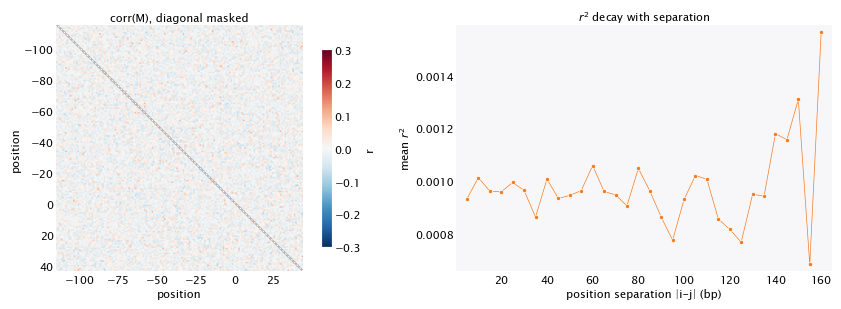

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

im = axes[0].imshow(R_display, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
                     extent=[pos[0], pos[-1], pos[-1], pos[0]])
axes[0].set_xlabel("position")
axes[0].set_ylabel("position")
axes[0].set_title("corr(M), diagonal masked")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="r")

axes[1].plot(bins[1:], mean_r2_by_sep, marker="o", markersize=3,
             color=regseq2.viz.my_color_dict["orange1"])
axes[1].set_xlabel("position separation |i-j| (bp)")
axes[1].set_ylabel(r"mean $r^2$")
axes[1].set_title(r"$r^2$ decay with separation")
fig.tight_layout()

### Diagnostic 4 — predicted leakage vs. the observed marginal footprint

This is the diagnostic CHECKPOINT 1 turns on. If position `i` is correlated with
position `j` at `r_ij`, and `j` carries genuine marginal MI, a first-order estimate of
how much of that signal could leak into `i` purely through the correlation is
`r_ij² · MI(j)` — `r²` because MI-like quantities scale with shared variance, not
shared correlation directly (this is a linear, order-of-magnitude approximation, not an
exact information-theoretic identity; it only needs to be right to within a factor for
this check). Summing over all other positions gives a naive prediction of the leakage
component of position `i`'s own marginal MI:

`leakage[i] = Σ_{j≠i} r_ij² · MI_marginal(j)`

`MI_marginal` is `compute_MI`'s existing statistic — the same one Section 2 will
reproduce and validate, computed here (rather than deferred) because this diagnostic
needs it now.

In [14]:
df_mi_marginal = compute_MI(IND, PROMOTER)
mi_marginal = df_mi_marginal.sort_values("pos")["mut_info"].values
assert len(mi_marginal) == L

leakage = (R**2) @ mi_marginal
print("marginal MI   : min/median/max =", mi_marginal.min(), np.median(mi_marginal), mi_marginal.max())
print("predicted leak: min/median/max =", leakage.min(), np.median(leakage), leakage.max())

marginal MI   : min/median/max = 3.7285373176146254e-09 0.000356924388496444 0.013124632052914906
predicted leak: min/median/max = 8.905694430384151e-05 0.0001464347314670206 0.00027388219825509477


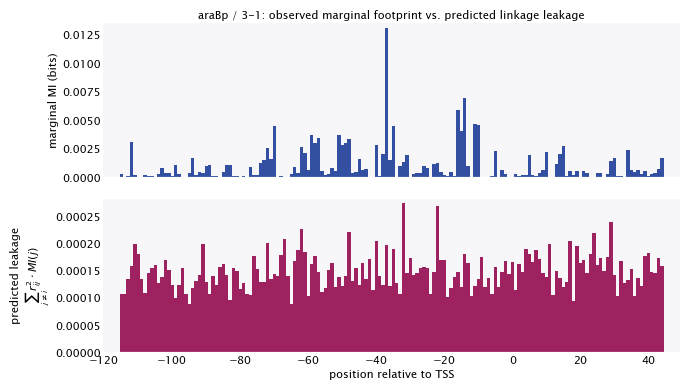

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
axes[0].bar(pos, mi_marginal, width=1, color=regseq2.viz.my_color_dict["blue1"])
axes[0].set_ylabel("marginal MI (bits)")
axes[0].set_title(f"{PROMOTER} / {IND}: observed marginal footprint vs. predicted linkage leakage")
axes[1].bar(pos, leakage, width=1, color=regseq2.viz.my_color_dict["purple1"])
axes[1].set_ylabel("predicted leakage\n" + r"$\sum_{j\neq i} r_{ij}^2 \cdot MI(j)$")
axes[1].set_xlabel("position relative to TSS")
fig.tight_layout()

In [16]:
ratio = np.divide(leakage, mi_marginal, out=np.full_like(leakage, np.nan), where=mi_marginal > 1e-12)
top10 = np.argsort(mi_marginal)[::-1][:10]

print(f"{'pos':>5}  {'mi_marginal':>11}  {'leakage':>10}  {'ratio':>7}")
for idx in top10:
    print(f"{pos[idx]:5d}  {mi_marginal[idx]:11.5f}  {leakage[idx]:10.6f}  {ratio[idx]:7.4f}")
print(f"\nratio range over the 10 highest-MI positions: {ratio[top10].min():.4f} - {ratio[top10].max():.4f}")

  pos  mi_marginal     leakage    ratio
  -37      0.01312    0.000197   0.0150
  -14      0.00693    0.000181   0.0261
  -16      0.00592    0.000148   0.0249
  -11      0.00470    0.000121   0.0258
  -10      0.00461    0.000135   0.0292
  -70      0.00452    0.000145   0.0320
  -35      0.00449    0.000190   0.0424
  -15      0.00408    0.000121   0.0296
  -59      0.00372    0.000162   0.0435
  -51      0.00368    0.000138   0.0376

ratio range over the 10 highest-MI positions: 0.0150 - 0.0435


### Diagnostic 5 — does the leakage finding replicate?

`3-1` and `3-2` are biological replicates of the same promoter/condition — independent
library preps and sequencing runs, not technical resequencing of the same sample. A
finding this notebook is about to lean on (linkage leakage doesn't explain the marginal
peaks) needs to hold up on a second, independent library, not just be a property of one
run. This repeats Diagnostic 4's `M` → `R` → `leakage` pipeline for `IND_REPLICATE_2`
verbatim rather than wrapping it in a function — it's only called twice, and writing it
out again makes it easy to see nothing but `IND` changed.

In [17]:
df_counts_rep2 = get_counts(IND_REPLICATE_2, PROMOTER)
total_reads_rep2 = df_counts_rep2["ct_0"] + df_counts_rep2["ct_1"]
df_var_rep2 = df_counts_rep2.loc[total_reads_rep2 > 0].reset_index(drop=True)

seqs_rep2 = df_var_rep2["promoter"].astype(str)
seq_arr_rep2 = np.frombuffer("".join(seqs_rep2.values).encode("ascii"), dtype=np.uint8).reshape(len(seqs_rep2), L)
M_rep2 = (seq_arr_rep2 != wt_arr[None, :]).astype(np.float64)

R_rep2 = np.corrcoef(M_rep2.T)
np.fill_diagonal(R_rep2, 0.0)

mi_marginal_rep2 = compute_MI(IND_REPLICATE_2, PROMOTER).sort_values("pos")["mut_info"].values
leakage_rep2 = (R_rep2**2) @ mi_marginal_rep2
ratio_rep2 = np.divide(leakage_rep2, mi_marginal_rep2,
                        out=np.full_like(leakage_rep2, np.nan), where=mi_marginal_rep2 > 1e-12)
top10_rep2 = np.argsort(mi_marginal_rep2)[::-1][:10]

print(f"{IND}: n_variants={M.shape[0]:5d}  top10 ratio range = {ratio[top10].min():.4f} - {ratio[top10].max():.4f}")
print(f"{IND_REPLICATE_2}: n_variants={M_rep2.shape[0]:5d}  top10 ratio range = {ratio_rep2[top10_rep2].min():.4f} - {ratio_rep2[top10_rep2].max():.4f}")

top10_positions = set(pos[top10].tolist())
top10_positions_rep2 = set(pos[top10_rep2].tolist())
print(f"\ntop-10 positions, {IND}     : {sorted(top10_positions)}")
print(f"top-10 positions, {IND_REPLICATE_2}: {sorted(top10_positions_rep2)}")
print(f"overlap: {len(top10_positions & top10_positions_rep2)}/10")


3-1: n_variants= 6131  top10 ratio range = 0.0150 - 0.0435
3-2: n_variants=15655  top10 ratio range = 0.0080 - 0.0392

top-10 positions, 3-1     : [-70, -59, -51, -37, -35, -16, -15, -14, -11, -10]
top-10 positions, 3-2: [-62, -59, -51, -37, -35, -16, -15, -14, -11, -10]
overlap: 9/10


### Diagnostic 6 — barcode-level reproducibility across replicates

Diagnostics 1-5 all work at the position level, aggregated over thousands of barcodes.
That aggregation can hide a lot: if individual barcodes are noisy but the noise
averages out across the many barcodes sharing a mutation at a given position, the
position-level statistic can still look clean. This checks the noise directly, at the
level it actually happens — one barcode at a time.

Barcodes are assigned once during library construction and tracked by the same
barcode→promoter mapping table regardless of growth condition, so a barcode present in
both `3-1` and `3-2` is the same physical clone, sequenced after two independent
growth+harvest+sequencing runs. That makes a per-barcode comparison a real biological
replicate check, not just a resampling exercise.

Expression per barcode is defined as `log2((n_rna + 1) / (n_dna + 1))` — a log-ratio
(so it's symmetric in RNA vs. DNA, matching how `compute_MI`/the GLM already treat the
two count streams) with a `+1` pseudocount to handle barcodes with zero DNA or zero RNA
reads without producing `-inf`/`inf`. The alternative, a raw ratio or the RNA fraction
`n_rna/(n_rna+n_dna)`, avoids picking a pseudocount but is heavily right-skewed and
compresses hard at the extremes; the log-ratio is the more standard choice for this
kind of count-ratio data and is what's used below.

In [18]:
barcodes_common = df_var[["barcode", "ct_0", "ct_1"]].merge(
    df_var_rep2[["barcode", "ct_0", "ct_1"]], on="barcode", suffixes=("_1", "_2")
)
expr_1 = np.log2((barcodes_common["ct_1_1"] + 1) / (barcodes_common["ct_0_1"] + 1))
expr_2 = np.log2((barcodes_common["ct_1_2"] + 1) / (barcodes_common["ct_0_2"] + 1))

r_pearson = np.corrcoef(expr_1, expr_2)[0, 1]
r_spearman = stats.spearmanr(expr_1, expr_2).statistic

print(f"barcodes in {IND} : {len(df_var)}")
print(f"barcodes in {IND_REPLICATE_2}: {len(df_var_rep2)}")
print(f"barcodes common to both     : {len(barcodes_common)}")
print(f"\npearson r  = {r_pearson:.3f}  (r^2 = {r_pearson**2:.3f})")
print(f"spearman r = {r_spearman:.3f}")


barcodes in 3-1 : 6131
barcodes in 3-2: 15655
barcodes common to both     : 5783

pearson r  = 0.393  (r^2 = 0.155)
spearman r = 0.281


That correlation is modest, and most common barcodes are shallow: `3-1` averages
2.7 reads/variant overall (well below `3-2`'s 19.9), so a barcode's log-ratio is often
built from single-digit counts on at least one side — mostly Poisson counting noise,
not necessarily a real cross-condition discrepancy. If that's the explanation, r should
climb as the comparison is restricted to higher-depth barcodes on both sides. If it's a
genuine reproducibility ceiling instead, r should plateau. This isn't a filter applied
anywhere else in the notebook — it's a diagnostic sweep to tell the two apart.

In [19]:
depth_1 = barcodes_common["ct_0_1"] + barcodes_common["ct_1_1"]
depth_2 = barcodes_common["ct_0_2"] + barcodes_common["ct_1_2"]

print(f"{'min_depth':>9}  {'n':>6}  {'pearson r':>9}")
for min_depth in [0, 5, 10, 20]:
    mask = (depth_1 >= min_depth) & (depth_2 >= min_depth)
    r = np.corrcoef(expr_1[mask], expr_2[mask])[0, 1]
    print(f"{min_depth:9d}  {mask.sum():6d}  {r:9.3f}")


min_depth       n  pearson r
        0    5783      0.393
        5     704      0.534
       10     220      0.550
       20      73      0.482


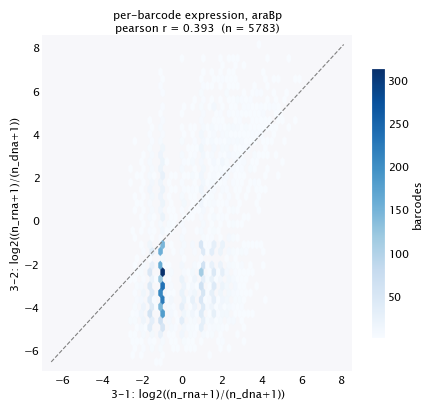

In [20]:
fig, ax = plt.subplots(figsize=(4.5, 4.2))
hb = ax.hexbin(expr_1, expr_2, gridsize=40, cmap="Blues", mincnt=1)
lims = [min(expr_1.min(), expr_2.min()), max(expr_1.max(), expr_2.max())]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"{IND}: log2((n_rna+1)/(n_dna+1))")
ax.set_ylabel(f"{IND_REPLICATE_2}: log2((n_rna+1)/(n_dna+1))")
ax.set_title(f"per-barcode expression, {PROMOTER}\npearson r = {r_pearson:.3f}  (n = {len(barcodes_common)})")
fig.colorbar(hb, ax=ax, shrink=0.8, label="barcodes")
fig.tight_layout()


### Diagnostic 7 — is the barcode-level noise coming from the RNA side specifically?

There's a standing hypothesis from earlier work on this data: not enough RNA molecules
were recovered during extraction, so RNA counts suffer from zero-inflation that DNA
counts don't. Diagnostic 6 showed barcode-level noise exists; it didn't say which
channel it comes from. That's checkable directly, because `ct_0` (DNA) and `ct_1`
(RNA) are measured on the *same* barcodes in the *same* sequencing run — any asymmetry
between them isn't explained by overall run quality, only by something specific to one
channel's sampling.

First check: raw zero rate and dispersion (`var/mean`, where 1.0 is what plain Poisson
counting noise gives) for each channel, both replicates.

In [21]:
n_dna_rep2 = df_var_rep2["ct_0"].values.astype(np.int64)
n_rna_rep2 = df_var_rep2["ct_1"].values.astype(np.int64)

print(f"{'':>6}  {'P(DNA=0)':>9}  {'P(RNA=0)':>9}  {'var/mean DNA':>13}  {'var/mean RNA':>13}")
for label, dna, rna in [(IND, n_dna, n_rna), (IND_REPLICATE_2, n_dna_rep2, n_rna_rep2)]:
    dna, rna = dna.astype(float), rna.astype(float)
    print(f"{label:>6}  {np.mean(dna == 0):9.3f}  {np.mean(rna == 0):9.3f}  "
          f"{dna.var() / dna.mean():13.2f}  {rna.var() / rna.mean():13.2f}")


         P(DNA=0)   P(RNA=0)   var/mean DNA   var/mean RNA
   3-1      0.310      0.522           0.83          10.56
   3-2      0.012      0.833          10.23         228.23


Both channels show some skew, but RNA's dispersion is an order of magnitude (or more)
past DNA's in both replicates — far beyond ordinary counting noise. The sharpest test
of *why* is Diagnostic 1's `eff_n = (Σw)²/Σw²` metric, now applied separately to each
channel instead of pooled: if RNA capture lost most of the molecular diversity before
sequencing ever happened, `eff_n(RNA)` should be small in absolute terms, and — this is
the key test — it should **not** grow just because `3-2` was sequenced ~8x deeper than
`3-1`. Re-sequencing a small surviving pool of molecules harder only re-reads the same
molecules more times; it doesn't discover new ones. `eff_n(DNA)` is the control: DNA
was never hypothesized to have this problem, so it's what "more depth helps" should
look like if that's true anywhere in this run.

In [22]:
def eff_n(x):
    x = x.astype(float)
    return x.sum()**2 / (x**2).sum()

print(f"{'':>6}  {'n_barcodes':>10}  {'eff_n(DNA)':>10}  {'%':>6}  {'eff_n(RNA)':>10}  {'%':>6}")
for label, n, dna, rna in [(IND, len(n_dna), n_dna, n_rna),
                           (IND_REPLICATE_2, len(n_dna_rep2), n_dna_rep2, n_rna_rep2)]:
    e_dna, e_rna = eff_n(dna), eff_n(rna)
    print(f"{label:>6}  {n:10d}  {e_dna:10.1f}  {e_dna/n:5.1%}  {e_rna:10.1f}  {e_rna/n:5.1%}")


        n_barcodes  eff_n(DNA)       %  eff_n(RNA)       %
   3-1        6131      3265.7  53.3%       883.8  14.4%
   3-2       15655      7104.0  45.4%       743.6   4.7%


A concentration (Lorenz-style) curve makes the same point visually: rank barcodes by
count within a channel, plot the cumulative share of that channel's reads held by the
top X% of barcodes. A channel drawing reads roughly evenly across the whole barcode
population sits close to the diagonal; a channel where a small subset of barcodes hold
most of the reads bows sharply toward the top-left, regardless of how many total reads
that channel has.

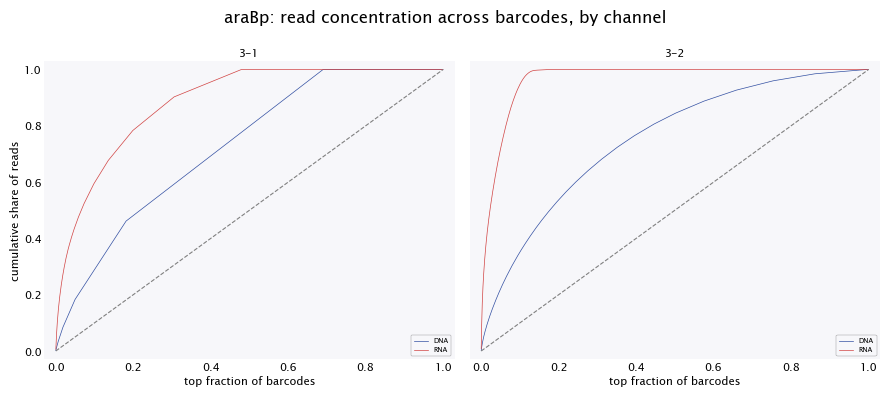

In [23]:
def cum_share(x):
    s = np.sort(x.astype(float))[::-1]
    return np.cumsum(s) / s.sum()

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, label, n, dna, rna in [(axes[0], IND, len(n_dna), n_dna, n_rna),
                                (axes[1], IND_REPLICATE_2, len(n_dna_rep2), n_dna_rep2, n_rna_rep2)]:
    barcode_rank_frac = np.arange(1, n + 1) / n
    ax.plot(barcode_rank_frac, cum_share(dna), color=regseq2.viz.my_color_dict["blue1"], label="DNA")
    ax.plot(barcode_rank_frac, cum_share(rna), color=regseq2.viz.my_color_dict["red1"], label="RNA")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("top fraction of barcodes")
    ax.set_title(label)
    ax.legend(loc="lower right")
axes[0].set_ylabel("cumulative share of reads")
fig.suptitle(f"{PROMOTER}: read concentration across barcodes, by channel")
fig.tight_layout()


### Diagnostic 7b — was capture the whole story, or is amplification uneven too?

A more specific version of the hypothesis: the bottleneck is at reverse transcription
(only a small fraction of RNA molecules get reverse-transcribed into cDNA at all), and
once a molecule clears that step, everything downstream (PCR, sequencing) amplifies it
roughly proportionally. That version makes a sharp prediction — capture is close to a
coin flip per molecule (all-or-nothing), so almost all of RNA's excess dispersion
should live in the *zero vs. nonzero* split. Restricting to barcodes that did get
captured (`n_rna > 0`) should then leave something close to ordinary Poisson noise
around each barcode's own mean, since "amplified evenly" means no extra stochastic
spread gets added after capture.

This is directly checkable by recomputing `var/mean` for RNA with the zero-count
barcodes excluded, and seeing how much of Diagnostic 7's overdispersion survives.

In [24]:
print(f"{'':>6}  {'overall var/mean':>17}  {'nonzero-only var/mean':>21}  {'n_nonzero':>9}")
for label, rna in [(IND, n_rna), (IND_REPLICATE_2, n_rna_rep2)]:
    rna = rna.astype(float)
    nz = rna[rna > 0]
    print(f"{label:>6}  {rna.var() / rna.mean():17.2f}  {nz.var() / nz.mean():21.2f}  {len(nz):9d}")


         overall var/mean  nonzero-only var/mean  n_nonzero
   3-1              10.56                   8.62       2931
   3-2             228.23                 171.27       2607


Excluding zeros barely moves the number: `3-1` goes from 10.6x to 8.6x Poisson, `3-2`
from 228x to 171x. If capture were an all-or-nothing coin flip followed by even
amplification, this should have dropped to something near 1.0. It didn't — most of the
overdispersion lives *among* the captured molecules, not just in the zero/nonzero
split. Taken at face value, that argues against the "amplified evenly afterward" half
of the hypothesis specifically.

Two reasons not to take it fully at face value, though. First, these are different
sequence variants with genuinely different transcription rates — some of this
"nonzero-only" spread is real biological signal (the thing the whole assay is trying to
measure), not technical noise, and this check can't separate the two. Second, there are
no UMIs (unique molecular identifiers) in this data to distinguish "several different
molecules were captured and amplified" from "one molecule was captured and PCR
amplified unevenly into many reads" — both look identical in a read count. So this
check can't cleanly confirm *or* rule out uneven amplification; it only shows that
whatever is happening to the captured molecules, it isn't simple, low-noise, even
scaling. The RT-capture bottleneck itself (Diagnostic 7) rests on firmer ground, since
comparing against DNA in the same barcodes isn't subject to either confound.

## CHECKPOINT 1

At the ten highest marginal-MI positions — the peaks a caller would actually flag —
predicted leakage is **0.0150–0.0435** of the observed marginal MI in replicate `3-1`
(roughly 23-67x smaller), and the tallest marginal peak (position -37, MI = 0.0131
bits) sits over a predicted leakage of 0.0002 bits, near the flat, noisy floor the
leakage track sits at almost everywhere else. The `r²`-vs-separation curve
(Diagnostic 3) is flat within noise (near/far ratio ≈ 1), meaning there is no
detectable spatial linkage structure in this library at all — mutations land close to
independently of each other regardless of distance.

Diagnostic 5 repeats this on the second biological replicate, `3-2` (an independent
library prep and sequencing run, roughly 2.5x more variants than `3-1`), and it holds
up: leakage ratio 0.0080–0.0392 at its own top-10 positions, and 9 of the top-10
highest-MI positions are identical between the two replicates. This is not one library's
idiosyncrasy — it's a consistent property of this promoter/condition.

Diagnostic 6 explains *why* that reproducibility is worth trusting despite what
individual barcodes look like: per-barcode expression correlates only weakly between
`3-1` and `3-2` (pearson r = 0.393, r² = 0.155, n = 5783 shared barcodes), and that
weak correlation is substantially a depth artifact — restricting to barcodes with
≥5-10 reads on both sides raises r to ~0.53-0.55 (n drops to a few hundred, so this
isn't the final word on the ceiling, just enough to show depth is a real driver).

**Diagnostic 7 confirms the earlier hypothesis and localizes it: the barcode-level
noise is coming from the RNA side specifically, not general sequencing noise.** Within
the same barcodes in the same run, RNA counts are far more dispersed than DNA counts
(`var/mean` = 10.6 vs. 0.8 in `3-1`; 228 vs. 10 in `3-2` — DNA is close to Poisson, RNA
is nowhere near it), and RNA reads concentrate onto a small subset of barcodes while
DNA reads spread much more broadly (Lorenz-style plot). Quantified as an effective
sample size, `eff_n(RNA)` is only 14.4% of nominal barcodes in `3-1` and just **4.7%**
in `3-2` — versus 53.3%/45.4% for `eff_n(DNA)` in the same runs. The decisive point:
`3-2` has ~8x `3-1`'s total read depth, and DNA's effective diversity scales with that
roughly as expected (3266 → 7104), but RNA's effective diversity does not — it actually
*drops* in absolute terms (884 → 744) even as nominal RNA reads and barcode counts both
grow enormously. Sequencing harder just re-reads the same small surviving pool of RNA
molecules more times; it doesn't recover diversity that was never captured. That is
precisely the signature a bottleneck upstream of sequencing predicts (proposed
mechanism: reverse transcription capturing only a small fraction of RNA molecules), and
DNA (never suspected of this problem, and not subject to an RT step at all) is the
control showing normal behavior in the same data.

Diagnostic 7b tested the natural follow-on claim — that once past the RT bottleneck,
everything downstream amplifies roughly evenly — by asking whether RNA's overdispersion
is mostly the zero/nonzero split (consistent with "even amplification") or persists
among the captured (nonzero) barcodes too. It persists: excluding zeros only takes
`var/mean` from 10.6x to 8.6x Poisson in `3-1`, and 228x to 171x in `3-2`. So the
capture-bottleneck part of the hypothesis is well supported; the "amplified evenly
afterward" part is not confirmed by this check, though it isn't cleanly ruled out
either — real variant-to-variant expression differences and the absence of UMIs (so PCR
duplicates of one captured molecule can't be distinguished from several independently
captured molecules) both confound that specific question. Either way, this is a more
specific, more concrete reason for caution than "low depth" in general: RNA counts for
most barcodes look close to arbitrary, driven by a molecule-capture lottery rather than
that barcode's actual expression, and that unevenness doesn't fully explain itself away
once a molecule clears the RT step.

Per the spec's stated criterion: predicted linkage leakage is orders of magnitude
smaller than the observed marginal MI at the positions a caller would flag, in both
replicates. **Linkage between positions, as captured by pairwise correlation in `M`, is
not what is producing the marginal peaks for `araBp` under arabinose.** If some of
those peaks are in fact not real binding sites, pairwise linkage leakage is not the
mechanism responsible, and the conditional/joint model this notebook was set up to
build is not expected to shrink them — a joint fit only removes variance that positions
actually share, and Diagnostics 3-5 show there is very little of that to remove here.

This does not mean the marginal footprint is trustworthy as-is — Diagnostics 7/7b are a
more concrete reason for caution than the general "low depth" concern raised earlier.
Ways this could still be worth pursuing: (a) a different promoter or condition with
denser/more structured mutagenesis could show real positional linkage where this one
doesn't — worth spot checking before generalizing the linkage conclusion beyond
araBp/arabinose; (b) whatever produces spurious peaks here, if anything does, is more
likely to be RNA-side capture noise (Diagnostics 7/7b) than pairwise linkage — a
two-position correlation diagnostic wouldn't catch that, and neither would the joint
logistic model in Section 3 as specified, since it fits `n_rna` directly as-is rather
than modeling an RNA-capture step; (c) if RNA molecule loss at the RT step is confirmed
as the mechanism, the fix is upstream of this notebook (library prep protocol), not a
statistical correction applied here.

**Stopping here per the spec.** Sections 2 onward are not built in this pass.
